In [20]:
import sys
import os

# detect the environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# configure the paths
if IN_COLAB:
    print("Running in Google Colab. Setting up GitHub repo...")
    REPO_URL = "https://github.com/JayC-SF/COMP-432-Project.git"
    REPO_DIR = "/content/COMP-432-Project"
    
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
        
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
    
    !pip install optuna
    
    # change the working directory
    os.chdir(REPO_DIR)
else:
    print("Running locally. Setting up relative paths...")
    # move up only if base directory is at notebooks
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
        print(f"Working directory changed to: {os.getcwd()}")
    
    # add working dir to sys path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())
        
    %load_ext autoreload
    %autoreload 2

from src import preprocess_data as prepd
from src.models.NN import CustomResNet
import src.variables as v
import numpy as np
import torch
from src.train.orchestrator import Orchestrator
from src.utils.hardware import get_device
from src.utils.seed import set_seed
from src.datasets import ICSD_MelSpectogram
from torch.utils.data import DataLoader
import copy
import gc
import optuna
import joblib
import src.utils.plotting as plotting
import pandas as pd
set_seed(v.SEED)

Running locally. Setting up relative paths...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Seed set to: 42


Download the mel spectogram `.npz` dataset.

In [2]:
prepd.download_google_file(v.MEL_SPECTOGRAM_NPZ_FILE_PATH, v.MEL_SPECTOGRAM_NPZ_GID)

data/mel_spectogram_audio_length_adjusted.npz already exists.


In [3]:
data = np.load(v.MEL_SPECTOGRAM_NPZ_FILE_PATH)
train_ds = ICSD_MelSpectogram(data['X_train'], data['y_train'])
val_ds = ICSD_MelSpectogram(data['X_val'], data['y_val'])
test_ds = ICSD_MelSpectogram(data['X_test'], data['y_test'])

We load the dataset into their respective splits

In [4]:
set_seed(v.SEED)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

✅ Seed set to: 42


In [5]:
def create_orchestrator(name, lr, wd, trial=None):
    set_seed(v.SEED)
    
    # use output 2 classes so we can use standard multi class logic for training orchestrator
    LEARNING_RATE = lr
    WEIGHT_DECAY = wd
    PATIENCE = 15
    SAVE_PATH = v.RUNS_PATH/name
    MAX_EPOCHS = 500
    model = CustomResNet(2)
    DEVICE = get_device()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        weight_decay = WEIGHT_DECAY,
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=40
    )
    criterion = torch.nn.CrossEntropyLoss()

    orchestrator = Orchestrator(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        patience=PATIENCE,
        save_path=SAVE_PATH,
        scheduler=scheduler,
        max_epochs=MAX_EPOCHS,
        classes=v.CLASSES,
        trial=trial
    )

    return orchestrator

def train_model(name, lr, wd, trial=None):
    orchestrator = create_orchestrator(name, lr, wd, trial)
    print(f"\n🚀 Training {name} | LR: {lr} | WD: {wd}")
    if trial is None:
        print(f"📂 Saving to: {orchestrator.save_path}")

    orchestrator.train()
    return orchestrator




In [21]:
orchestrator_resnet_baseline = train_model(name="CustomResnet_baseline", lr=1e-4, wd=1e-3)

✅ Seed set to: 42

🚀 Training CustomResnet_baseline | LR: 0.0001 | WD: 0.001
📂 Saving to: runs\CustomResnet_baseline
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.3702 | Train Acc: 85.0863%


Val Loss: 0.4041 | Val Acc: 85.1201%
📉 Learning rate reduced to 9.98e-05
Saved checkpoint data under runs\CustomResnet_baseline\latest_history.pt
🌟 New Best Model! Val Loss decreased from inf to 0.4041
Saved best_model_weights under runs\CustomResnet_baseline\best_model.pt
---- Starting Epoch 2 ----


Train Loss: 0.2322 | Train Acc: 92.0791%


Val Loss: 0.2721 | Val Acc: 90.2033%
📉 Learning rate reduced to 9.94e-05
Saved checkpoint data under runs\CustomResnet_baseline\latest_history.pt
🌟 New Best Model! Val Loss decreased from 0.4041 to 0.2721
Saved best_model_weights under runs\CustomResnet_baseline\best_model.pt
---- Starting Epoch 3 ----


...

Val Loss: 0.1713 | Val Acc: 95.3789%
📉 Learning rate reduced to 4.61e-05
Saved checkpoint data under runs\CustomResnet_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 22 ----


Train Loss: 0.0047 | Train Acc: 99.9512%


Val Loss: 0.1660 | Val Acc: 94.8244%
📉 Learning rate reduced to 4.22e-05
Saved checkpoint data under runs\CustomResnet_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 23 ----


Train Loss: 0.0031 | Train Acc: 99.9756%


Val Loss: 0.1856 | Val Acc: 95.2865%
📉 Learning rate reduced to 3.83e-05
Saved checkpoint data under runs\CustomResnet_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 23


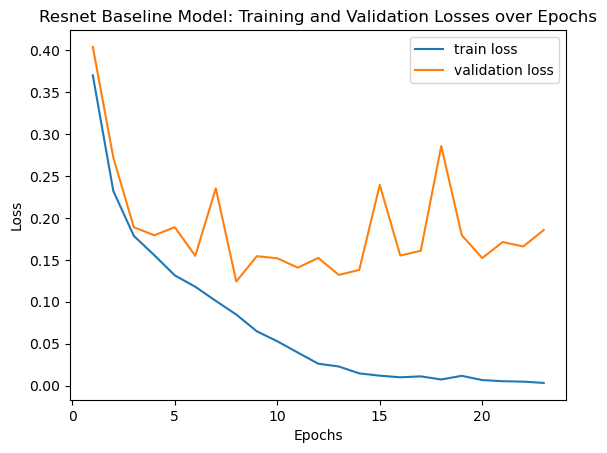

Best epoch's validation loss (0.12412985875624165) achieved at epoch 8
Best epoch's training loss (0.08472675779420132)
Total epochs (23)


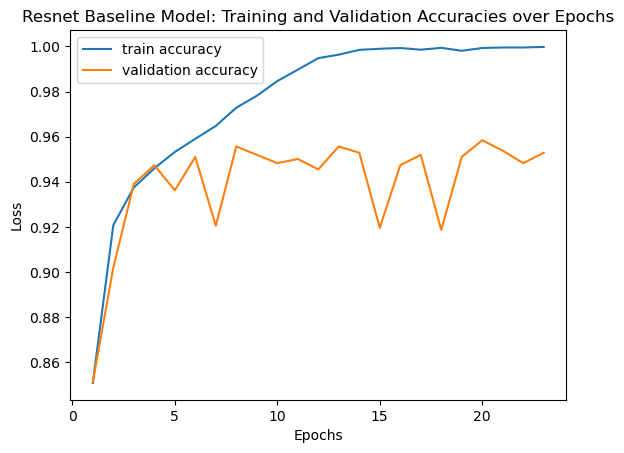

Best epoch's validation accuracy: 95.563771%
Best epoch's training accuracy: 97.281016%


In [12]:
plotting.plot_orchestrator_training_summary(orchestrator_resnet_baseline, "Resnet Baseline Model")

In [10]:
best_weights = orchestrator_resnet_baseline.th.best_model_weights
results_resnet_baseline = orchestrator_resnet_baseline.test(test_loader, best_weights)

Test Loss: 0.0988 | Test Acc: 96.6728%


              precision    recall  f1-score   support

     Snoring       0.97      0.96      0.97       539
   InfantCry       0.96      0.97      0.97       543

    accuracy                           0.97      1082
   macro avg       0.97      0.97      0.97      1082
weighted avg       0.97      0.97      0.97      1082



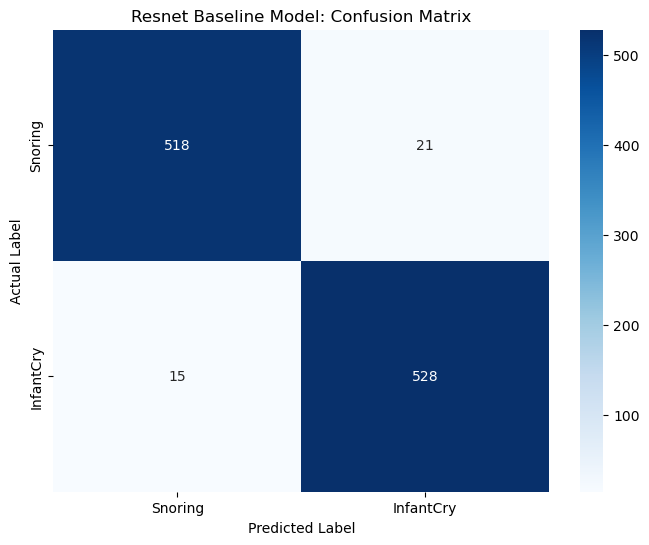

Test Loss: 0.0988 | Test Acc: 96.6728%


In [11]:
plotting.plot_test_results(results_resnet_baseline,"Resnet Baseline Model")

In [10]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 8e-4, log=True)
    wd = trial.suggest_float("wd", 1e-4, 5e-2, log=True)
    
    orchestrator = train_model(name=f"CustomResnet_trial_{trial.number}", lr=lr, wd=wd, trial=trial)
    
    best_val_loss = orchestrator.th.best_val_loss
    
    del orchestrator
    gc.collect() 
    torch.cuda.empty_cache()
    
    return best_val_loss

In [11]:
study = optuna.create_study(
    direction="minimize", 
    study_name="CustomResnet_ICSD_Optimization"
)

study.optimize(objective, n_trials=15)
# Save the study object to a file
joblib.dump(study, v.RUNS_PATH/"CustomResnet_ICSD_Optimization_Optuna_Study.pkl")

[I 2026-04-19 03:32:43,571] A new study created in memory with name: CustomResnet_ICSD_Optimization


✅ Seed set to: 42

🚀 Training CustomResnet_trial_0 | LR: 0.00020970098607901475 | WD: 0.00103932626576812
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.3377 | Train Acc: 86.6656%


Val Loss: 0.3095 | Val Acc: 87.6155%
📉 Learning rate reduced to 2.09e-04
🌟 New Best Model! Val Loss decreased from inf to 0.3095
---- Starting Epoch 2 ----


Train Loss: 0.1989 | Train Acc: 92.9827%


...

Val Loss: 0.1011 | Val Acc: 96.8577%
📉 Learning rate reduced to 5.85e-05
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 34 ----


Train Loss: 0.0009 | Train Acc: 99.9756%


[I 2026-04-19 12:23:57,901] Trial 14 finished with value: 0.080359036099448 and parameters: {'lr': 0.0007938990750990815, 'wd': 0.001832465296770582}. Best is trial 14 with value: 0.080359036099448.


Val Loss: 0.0983 | Val Acc: 96.7652%
📉 Learning rate reduced to 4.33e-05
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 34


['runs\\CustomResnet_ICSD_Optimization_Optuna_Study.pkl']

In [ ]:
optuna_fname = "CustomResnet_ICSD_Optimization_Optuna_Study"
joblib.dump(study, v.RUNS_PATH/f"{optuna_fname}.pkl")
fine_tune_history_df = study.trials_dataframe()
fine_tune_history_df.to_csv(v.RUNS_PATH/f"{optuna_fname}.csv", index=False)

In [21]:
# to avoid re running things
fine_tune_history_df = pd.read_csv(v.RUNS_PATH/f"{optuna_fname}.csv")
fine_tune_history_df

,number,value,datetime_start,datetime_complete,duration,params_lr,params_wd,state
0,0,0.112534,2026-04-19 03:32:43.572993,2026-04-19 04:05:33.991490,0 days 00:32:50.418497,0.000210,0.001039,COMPLETE
1,1,0.185569,2026-04-19 04:05:33.992490,2026-04-19 06:18:12.002490,0 days 02:12:38.010000,0.000010,0.003108,COMPLETE
2,2,0.138097,2026-04-19 06:18:12.003490,2026-04-19 07:01:46.977991,0 days 00:43:34.974501,0.000047,0.009942,COMPLETE
3,3,0.185451,2026-04-19 07:01:46.978992,2026-04-19 09:22:09.628990,0 days 02:20:22.649998,0.000011,0.000978,COMPLETE
4,4,0.135782,2026-04-19 09:22:09.629990,2026-04-19 10:02:00.382490,0 days 00:39:50.752500,0.000150,0.003096,COMPLETE
5,5,0.331103,2026-04-19 10:02:00.383990,2026-04-19 10:04:51.218990,0 days 00:02:50.835000,0.000214,0.000190,PRUNED
6,6,0.091144,2026-04-19 10:04:51.219490,2026-04-19 10:40:25.513490,0 days 00:35:34.294000,0.000304,0.000885,COMPLETE
7,7,0.131837,2026-04-19 10:40:25.513990,2026-04-19 11:23:06.244990,0 days 00:42:40.731000,0.000150,0.015912,COMPLETE
8,8,0.298744,2026-04-19 11:23:06.245991,2026-04-19 11:25:56.999989,0 days 00:02:50.753998,0.000050,0.015725,PRUNED
9,9,0.264560,2026-04-19 11:25:57.000489,2026-04-19 11:28:47.691489,0 days 00:02:50.691000,0.000097,0.000282,PRUNED


In [12]:
print("🎯 OPTIMIZATION COMPLETE")
print(f"Best Trial Score: {study.best_value:.4f}")
print(f"Best Hyperparameters: {study.best_params}")

🎯 OPTIMIZATION COMPLETE
Best Trial Score: 0.0804
Best Hyperparameters: {'lr': 0.0007938990750990815, 'wd': 0.001832465296770582}


In [ ]:
best_param_orchestrator = train_model(name="CustomResnet_best_params", lr=study.best_params['lr'], wd=study.best_params['wd'])

✅ Seed set to: 42

🚀 Training CustomResnet_best_params | LR: 0.0007938990750990815 | WD: 0.001832465296770582
📂 Saving to: runs\CustomResnet_best_params
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.3274 | Train Acc: 87.6425%


Val Loss: 0.4055 | Val Acc: 80.4991%
📉 Learning rate reduced to 7.93e-04
Saved checkpoint data under runs\CustomResnet_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from inf to 0.4055
Saved best_model_weights under runs\CustomResnet_best_params\best_model.pt
---- Starting Epoch 2 ----


Train Loss: 0.2140 | Train Acc: 92.5920%


Val Loss: 0.2303 | Val Acc: 92.6063%
📉 Learning rate reduced to 7.89e-04
Saved checkpoint data under runs\CustomResnet_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from 0.4055 to 0.2303
Saved best_model_weights under runs\CustomResnet_best_params\best_model.pt
---- Starting Epoch 3 ----


...

Val Loss: 0.0888 | Val Acc: 97.2274%
📉 Learning rate reduced to 7.58e-05
Saved checkpoint data under runs\CustomResnet_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 33 ----


Train Loss: 0.0009 | Train Acc: 99.9756%


Val Loss: 0.1011 | Val Acc: 96.8577%
📉 Learning rate reduced to 5.85e-05
Saved checkpoint data under runs\CustomResnet_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 34 ----


Train Loss: 0.0009 | Train Acc: 99.9756%


Val Loss: 0.0983 | Val Acc: 96.7652%
📉 Learning rate reduced to 4.33e-05
Saved checkpoint data under runs\CustomResnet_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 34


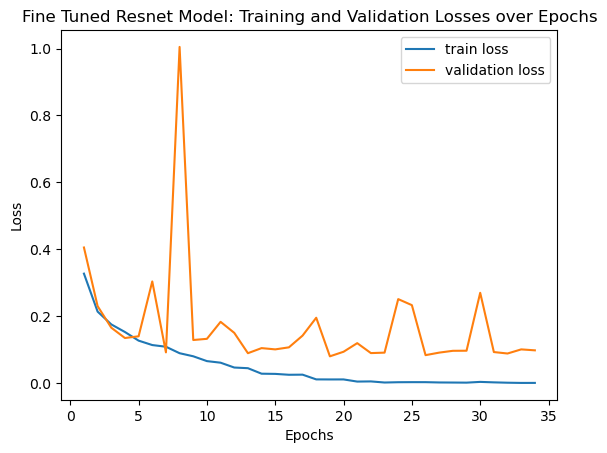

Best epoch's validation loss (0.080359036099448) achieved at epoch 19
Best epoch's training loss (0.011266060391558048)
Total epochs (34)


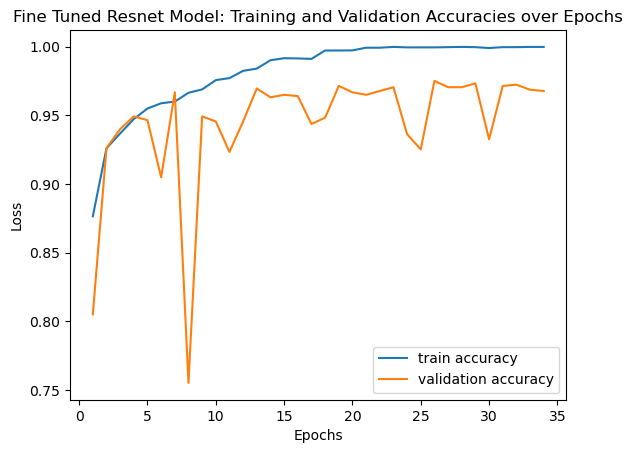

Best epoch's validation accuracy: 97.134935%
Best epoch's training accuracy: 99.715077%


In [14]:
plotting.plot_orchestrator_training_summary(best_param_orchestrator, "Fine Tuned Resnet Model")

In [15]:
best_param_results = best_param_orchestrator.test(test_loader, best_param_orchestrator.th.best_model_weights)


Test Loss: 0.0573 | Test Acc: 97.5046%


              precision    recall  f1-score   support

     Snoring       0.96      0.99      0.98       539
   InfantCry       0.99      0.96      0.97       543

    accuracy                           0.98      1082
   macro avg       0.98      0.98      0.98      1082
weighted avg       0.98      0.98      0.98      1082



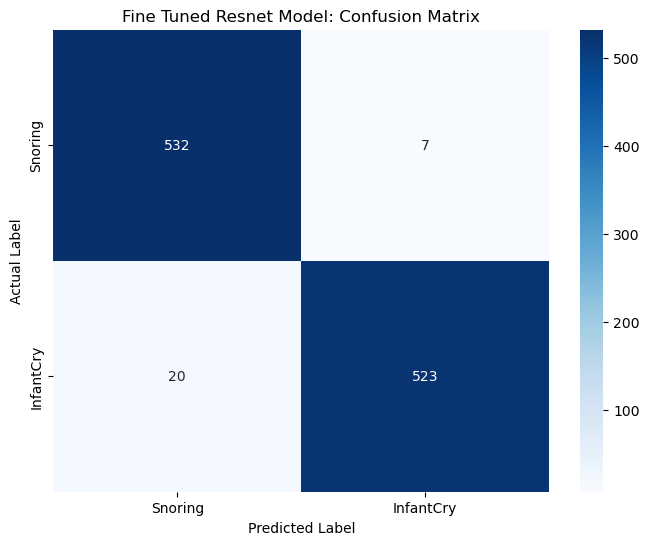

Test Loss: 0.0573 | Test Acc: 97.5046%


In [16]:
plotting.plot_test_results(best_param_results, "Fine Tuned Resnet Model")